In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

In [57]:
products = pd.read_csv("../data/raw/master/products.csv")
customers = pd.read_csv("../data/raw/master/customers.csv")
orders = pd.read_csv("../data/raw/transaction/orders.csv")
order_items = pd.read_csv("../data/raw/transaction/order_items.csv")
payments = pd.read_csv("../data/raw/transaction/payments.csv")
shipments = pd.read_csv("../data/raw/transaction/shipments.csv")
geography = pd.read_csv("../data/raw/master/geography.csv")
returns = pd.read_csv("../data/raw/transaction/returns.csv")
web_traffic = pd.read_csv("../data/raw/analytics-operational/web_traffic.csv")
sales = pd.read_csv("../data/raw/analytics-operational/sales.csv")

C:\Users\Admin\AppData\Local\Temp\ipykernel_11756\841969939.py:4: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("../data/raw/transaction/order_items.csv")


# Data.info()

In [58]:
datasets = {
    "products": products,
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "shipments": shipments,
    "geography": geography,
    "returns": returns,
    "web_traffic": web_traffic,
    "sales": sales,
}

for name, df in datasets.items():
    print(f"\n{'=' * 50}")
    print(f"Dataset: {name.upper()}")
    print(f"{'=' * 50}")
    df.info()


Dataset: PRODUCTS
<class 'pandas.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   str    
 2   category      2412 non-null   str    
 3   segment       2412 non-null   str    
 4   size          2412 non-null   str    
 5   color         2412 non-null   str    
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 150.9 KB

Dataset: CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   customer_id          121930 non-null  int64
 1   zip                  121930 non-null  int64
 2   city                 121930 non-null  str  
 3   signup_date          121930

## 1. Data Quality Overview - Duplicates Check

Checking for duplicates in each dataset:

PRODUCTS: 0 duplicate rows
CUSTOMERS: 0 duplicate rows
ORDERS: 0 duplicate rows
ORDER_ITEMS: 0 duplicate rows
PAYMENTS: 0 duplicate rows
SHIPMENTS: 0 duplicate rows
GEOGRAPHY: 0 duplicate rows
RETURNS: 0 duplicate rows
WEB_TRAFFIC: 0 duplicate rows
SALES: 0 duplicate rows


C:\Users\Admin\AppData\Local\Temp\ipykernel_11756\3469863666.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(duplicate_counts.keys(), rotation=45, ha="right")


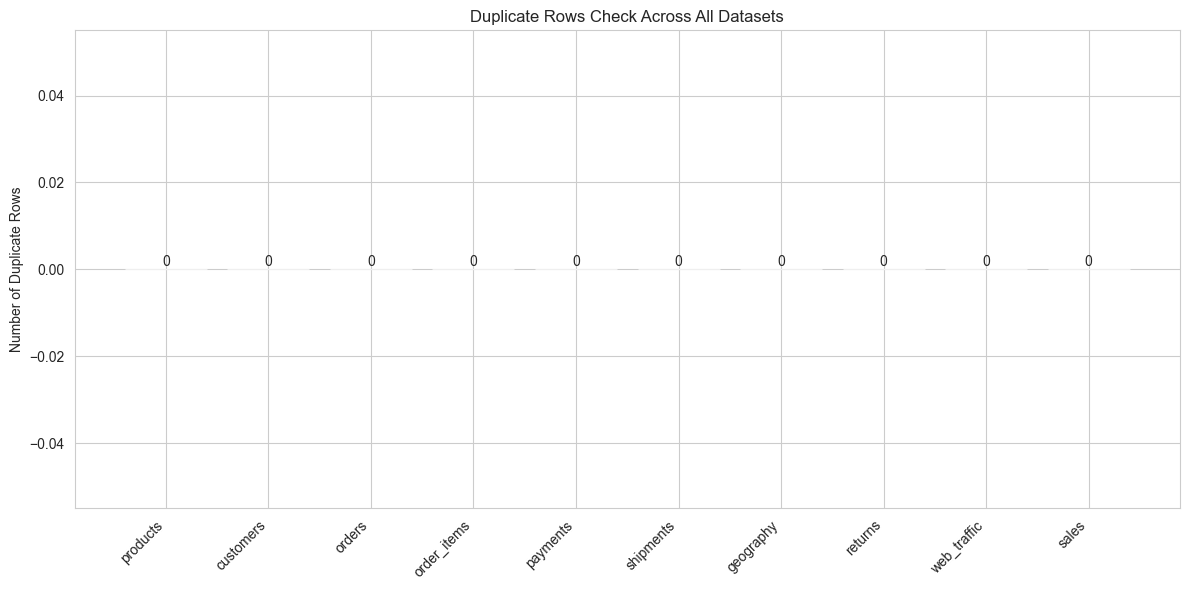

In [59]:
datasets = {
    "products": products,
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "shipments": shipments,
    "geography": geography,
    "returns": returns,
    "web_traffic": web_traffic,
    "sales": sales,
}

print("Checking for duplicates in each dataset:\n")

duplicate_counts = {}
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    duplicate_counts[name] = duplicates
    print(f"{name.upper()}: {duplicates} duplicate rows")

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["green" if v == 0 else "red" for v in duplicate_counts.values()]
ax.bar(duplicate_counts.keys(), duplicate_counts.values(), color=colors, alpha=0.7)
ax.set_ylabel("Number of Duplicate Rows")
ax.set_title("Duplicate Rows Check Across All Datasets")
ax.set_xticklabels(duplicate_counts.keys(), rotation=45, ha="right")
for i, (k, v) in enumerate(duplicate_counts.items()):
    ax.text(
        i, v + max(duplicate_counts.values()) * 0.02, str(v), ha="center", va="bottom"
    )
plt.tight_layout()
plt.show()

## 2. Numeric Data Analysis - Descriptive Statistics & Distribution

DESCRIPTIVE STATISTICS - NUMERIC COLUMNS

PRODUCTS:
       product_id     price      cogs
count     2412.00   2412.00   2412.00
mean      1206.50   4928.22   3868.35
std        696.43   4776.74   3878.58
min          1.00      9.06      5.18
25%        603.75     59.44     35.07
50%       1206.50   4399.60   3184.93
75%       1809.25   7720.51   5864.92
max       2412.00  40950.00  38902.50

CUSTOMERS:
       customer_id        zip
count    121930.00  121930.00
mean      78736.90   50990.17
std       45492.20   26871.91
min           1.00    1001.00
25%       39343.50   28689.25
50%       78784.50   49835.00
75%      118156.75   73488.00
max      157563.00   99950.00

ORDERS:
        order_id  customer_id        zip
count  646945.00    646945.00  646945.00
mean   417189.47     84906.20   55410.74
std    240785.70     48446.92   28876.47
min         1.00         1.00    1001.00
25%    208728.00     41336.00   30904.00
50%    417211.00     87279.00   54129.00
75%    625628.00    133282.0

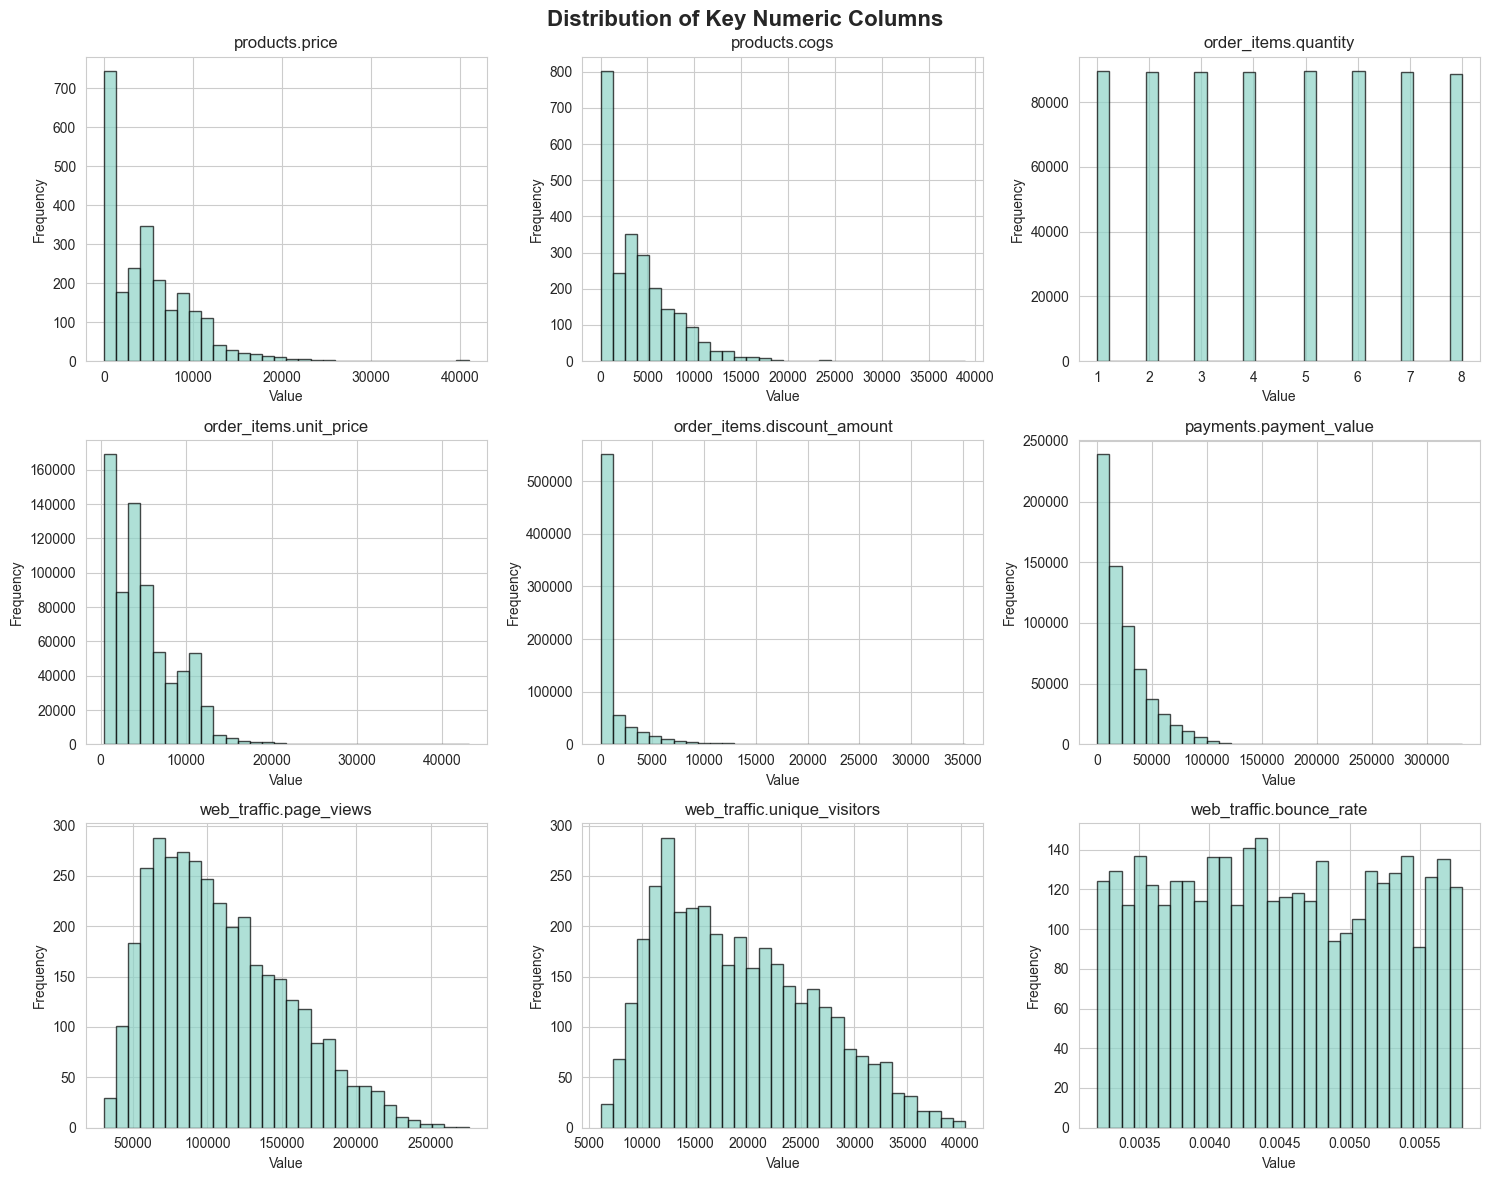

In [60]:
# Thống kê cơ bản (Descriptive Statistics)
print("=" * 60)
print("DESCRIPTIVE STATISTICS - NUMERIC COLUMNS")
print("=" * 60)

# Create visualizations for key numeric columns
important_numeric = {
    "products": ["price", "cogs"],
    "orders": ["quantity"],
    "order_items": ["quantity", "unit_price", "discount_amount"],
    "payments": ["payment_value"],
    "web_traffic": ["page_views", "unique_visitors", "bounce_rate"],
    "shipments": ["shipping_fee"],
    "sales": ["Revenue"],
}

for name, df in datasets.items():
    numeric_cols = df.select_dtypes(include=["number"]).columns
    if len(numeric_cols) > 0:
        print(f"\n{name.upper()}:")
        print(df[numeric_cols].describe().round(2))

# Distribution plots for important columns
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle("Distribution of Key Numeric Columns", fontsize=16, fontweight="bold")
axes = axes.flatten()

plot_idx = 0
for dataset_name, cols in important_numeric.items():
    if dataset_name in datasets:
        df = datasets[dataset_name]
        for col in cols:
            if col in df.columns and plot_idx < 9:
                df[col].hist(bins=30, ax=axes[plot_idx], edgecolor="black", alpha=0.7)
                axes[plot_idx].set_title(f"{dataset_name}.{col}")
                axes[plot_idx].set_xlabel("Value")
                axes[plot_idx].set_ylabel("Frequency")
                plot_idx += 1

# Hide unused subplots
for idx in range(plot_idx, 9):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## 3. Data Structure Overview - Column Info & Data Types

DATA TYPES OVERVIEW

PRODUCTS - Columns: 8, Rows: 2412
product_id        int64
product_name        str
category            str
segment             str
size                str
color               str
price           float64
cogs            float64
dtype: object

CUSTOMERS - Columns: 7, Rows: 121930
customer_id            int64
zip                    int64
city                     str
signup_date              str
gender                   str
age_group                str
acquisition_channel      str
dtype: object

ORDERS - Columns: 8, Rows: 646945
order_id          int64
order_date          str
customer_id       int64
zip               int64
order_status        str
payment_method      str
device_type         str
order_source        str
dtype: object

ORDER_ITEMS - Columns: 7, Rows: 714669
order_id             int64
product_id           int64
quantity             int64
unit_price         float64
discount_amount    float64
promo_id               str
promo_id_2             str
dtype: object


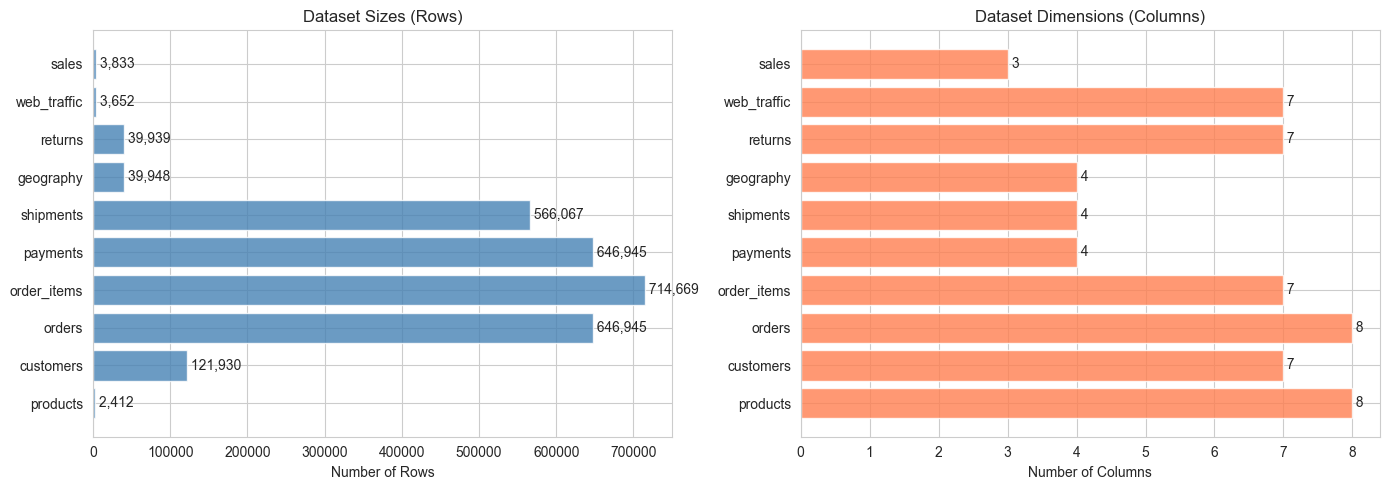

In [61]:
# Data Types & Column Overview
print("=" * 60)
print("DATA TYPES OVERVIEW")
print("=" * 60)

dataset_info = {}
for name, df in datasets.items():
    print(f"\n{name.upper()} - Columns: {df.shape[1]}, Rows: {df.shape[0]}")
    print(df.dtypes)
    dataset_info[name] = {"rows": df.shape[0], "cols": df.shape[1]}

# Visualization: Dataset sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

names = list(dataset_info.keys())
rows = [dataset_info[n]["rows"] for n in names]
cols = [dataset_info[n]["cols"] for n in names]

ax1.barh(names, rows, color="steelblue", alpha=0.8)
ax1.set_xlabel("Number of Rows")
ax1.set_title("Dataset Sizes (Rows)")
for i, v in enumerate(rows):
    ax1.text(v, i, f" {v:,}", va="center")

ax2.barh(names, cols, color="coral", alpha=0.8)
ax2.set_xlabel("Number of Columns")
ax2.set_title("Dataset Dimensions (Columns)")
for i, v in enumerate(cols):
    ax2.text(v, i, f" {v}", va="center")

plt.tight_layout()
plt.show()

FOREIGN KEY INTEGRITY CHECKS

orders.customer_id NOT in customers: 0 rows
order_items.order_id NOT in orders: 0 rows
order_items.product_id NOT in products: 0 rows
payments.order_id NOT in orders: 0 rows
shipments.order_id NOT in orders: 0 rows
returns.order_id NOT in orders: 0 rows
customers.zip NOT in geography: 0 rows


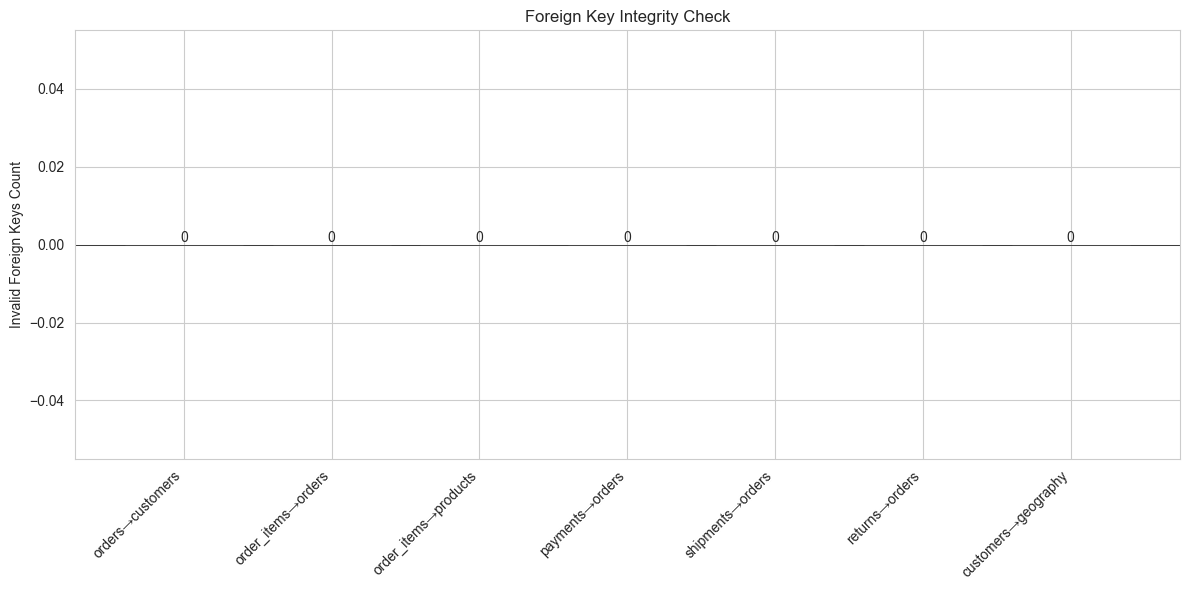

In [62]:
# Foreign Keys & Relationships Check
print("=" * 60)
print("FOREIGN KEY INTEGRITY CHECKS")
print("=" * 60)

# 1. Check orders.customer_id in customers
invalid_customers = orders[~orders["customer_id"].isin(customers["customer_id"])]
print(f"\norders.customer_id NOT in customers: {len(invalid_customers)} rows")

# 2. Check order_items.order_id in orders
invalid_orders = order_items[~order_items["order_id"].isin(orders["order_id"])]
print(f"order_items.order_id NOT in orders: {len(invalid_orders)} rows")

# 3. Check order_items.product_id in products
invalid_products = order_items[~order_items["product_id"].isin(products["product_id"])]
print(f"order_items.product_id NOT in products: {len(invalid_products)} rows")

# 4. Check payments.order_id in orders
invalid_order_payments = payments[~payments["order_id"].isin(orders["order_id"])]
print(f"payments.order_id NOT in orders: {len(invalid_order_payments)} rows")

# 5. Check shipments.order_id in orders
invalid_order_shipments = shipments[~shipments["order_id"].isin(orders["order_id"])]
print(f"shipments.order_id NOT in orders: {len(invalid_order_shipments)} rows")

# 6. Check returns.order_id in orders
invalid_order_returns = returns[~returns["order_id"].isin(orders["order_id"])]
print(f"returns.order_id NOT in orders: {len(invalid_order_returns)} rows")

# 7. Check customers.zip in geography
invalid_zip = customers[~customers["zip"].isin(geography["zip"])]
print(f"customers.zip NOT in geography: {len(invalid_zip)} rows")

# Visualization: FK Integrity Summary
fk_checks = {
    "orders→customers": len(invalid_customers),
    "order_items→orders": len(invalid_orders),
    "order_items→products": len(invalid_products),
    "payments→orders": len(invalid_order_payments),
    "shipments→orders": len(invalid_order_shipments),
    "returns→orders": len(invalid_order_returns),
    "customers→geography": len(invalid_zip),
}

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["green" if v == 0 else "red" for v in fk_checks.values()]
ax.bar(range(len(fk_checks)), fk_checks.values(), color=colors, alpha=0.7)
ax.set_xticks(range(len(fk_checks)))
ax.set_xticklabels(fk_checks.keys(), rotation=45, ha="right")
ax.set_ylabel("Invalid Foreign Keys Count")
ax.set_title("Foreign Key Integrity Check")
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
for i, (k, v) in enumerate(fk_checks.items()):
    ax.text(i, v + max(fk_checks.values()) * 0.02, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 4. Foreign Key & Referential Integrity Checks

OUTLIERS DETECTION (IQR Method)

products.price:
  Outliers: 31, Range: [-11432.16, 19212.12]

products.cogs:
  Outliers: 37, Range: [-8709.71, 14609.69]

order_items.unit_price:
  Outliers: 8623, Range: [-6143.41, 15324.07]

order_items.discount_amount:
  Outliers: 105767, Range: [-1451.44, 2419.07]

payments.payment_value:
  Outliers: 30219, Range: [-31356.87, 72744.29]

web_traffic.page_views:
  Outliers: 18, Range: [-24674.00, 235742.00]

shipments.shipping_fee:
  Outliers: 76050, Range: [-1.72, 5.20]

sales.Revenue:
  Outliers: 169, Range: [-1848593.75, 9670559.77]


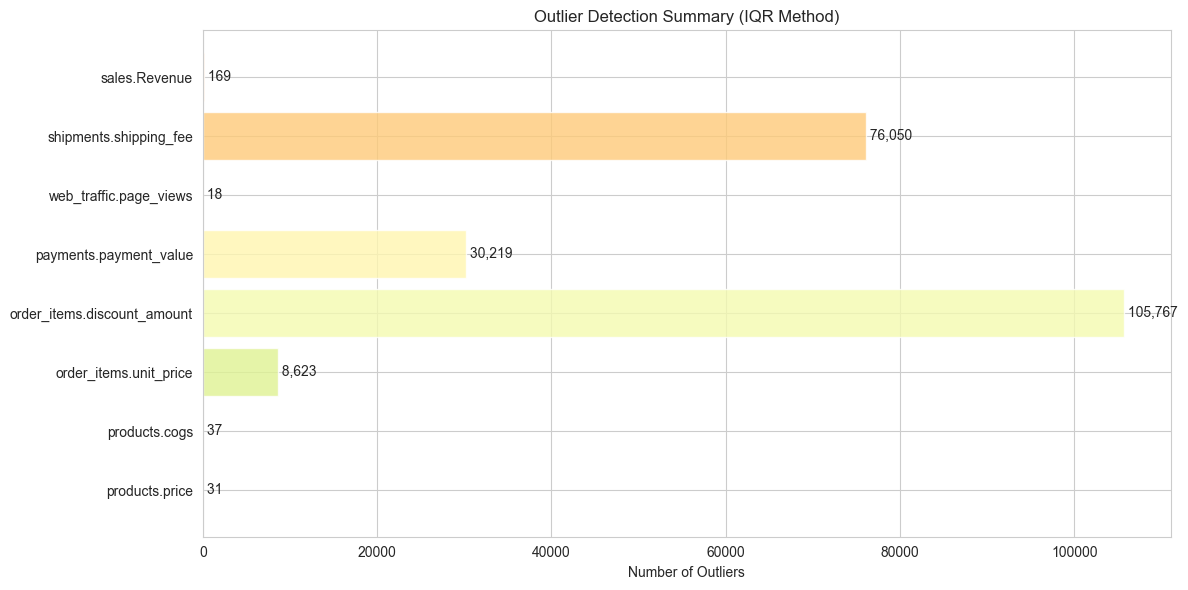

In [63]:
# Outliers Detection using IQR method
print("=" * 60)
print("OUTLIERS DETECTION (IQR Method)")
print("=" * 60)


def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound


# Check numeric columns for outliers
numeric_datasets = {
    "products": ["price", "cogs"],
    "order_items": ["quantity", "unit_price", "discount_amount"],
    "payments": ["payment_value"],
    "web_traffic": ["page_views", "unique_visitors", "bounce_rate", "session_duration"],
    "shipments": ["shipping_fee"],
    "sales": ["Revenue"] if "Revenue" in sales.columns else [],
}

outlier_summary = {}
for dataset_name, columns in numeric_datasets.items():
    if dataset_name in datasets:
        df = datasets[dataset_name]
        for col in columns:
            if col in df.columns:
                outlier_count, lower, upper = detect_outliers_iqr(df, col)
                if outlier_count > 0:
                    print(f"\n{dataset_name}.{col}:")
                    print(
                        f"  Outliers: {outlier_count}, Range: [{lower:.2f}, {upper:.2f}]"
                    )
                    outlier_summary[f"{dataset_name}.{col}"] = outlier_count

# Visualization: Outlier summary
if outlier_summary:
    fig, ax = plt.subplots(figsize=(12, 6))
    items = list(outlier_summary.keys())
    counts = list(outlier_summary.values())
    colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(counts)))
    ax.barh(items, counts, color=colors, alpha=0.8)
    ax.set_xlabel("Number of Outliers")
    ax.set_title("Outlier Detection Summary (IQR Method)")
    for i, v in enumerate(counts):
        ax.text(v, i, f" {v:,}", va="center")
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No significant outliers detected")

## 5. Outlier Detection & Distribution Analysis

In [64]:
# Constraints & Consistency Checks
print("=" * 60)
print("CONSTRAINTS & CONSISTENCY CHECKS")
print("=" * 60)

# 1. Check products: cogs < price (constraint from spec)
invalid_price = products[products["cogs"] >= products["price"]]
print(f"\n1. products.cogs >= products.price: {len(invalid_price)} rows")
if len(invalid_price) > 0:
    print(invalid_price[["product_id", "cogs", "price"]])

# 2. Check order_items & orders relationship
print(f"\n2. Checking order_items and orders relationship...")
order_item_counts = order_items.groupby("order_id").size()
orders_with_items = set(order_item_counts.index)
all_orders = set(orders["order_id"].unique())
orders_no_items = all_orders - orders_with_items
print(f"   Orders with no order_items: {len(orders_no_items)} rows")

# 3. Check shipments: ship_date should be after order_date
if "ship_date" in shipments.columns and "order_date" in orders.columns:
    shipments_check = shipments.merge(
        orders[["order_id", "order_date"]], on="order_id", how="left"
    )
    invalid_dates = shipments_check[
        shipments_check["ship_date"] < shipments_check["order_date"]
    ]
    print(f"\n3. shipments.ship_date < orders.order_date: {len(invalid_dates)} rows")

# 4. Check shipments: delivery_date should be after ship_date
if "delivery_date" in shipments.columns and "ship_date" in shipments.columns:
    invalid_delivery = shipments[shipments["delivery_date"] < shipments["ship_date"]]
    print(
        f"4. shipments.delivery_date < shipments.ship_date: {len(invalid_delivery)} rows"
    )

# 5. Check returns: return_date should be after order_date
if "return_date" in returns.columns and "order_date" in orders.columns:
    returns_check = returns.merge(
        orders[["order_id", "order_date"]], on="order_id", how="left"
    )
    invalid_return_dates = returns_check[
        returns_check["return_date"] < returns_check["order_date"]
    ]
    print(
        f"5. returns.return_date < orders.order_date: {len(invalid_return_dates)} rows"
    )

# 6. Check quantity > 0
print(
    f"\n6. order_items.quantity <= 0: {len(order_items[order_items['quantity'] <= 0])} rows"
)

# 7. Check prices > 0
print(
    f"7. order_items.unit_price <= 0: {len(order_items[order_items['unit_price'] <= 0])} rows"
)
print(f"   products.price <= 0: {len(products[products['price'] <= 0])} rows")

# 8. Check discount_amount >= 0
invalid_discount = order_items[order_items["discount_amount"] < 0]
print(f"8. order_items.discount_amount < 0: {len(invalid_discount)} rows")

# 9. Check shipping_fee >= 0
if "shipping_fee" in shipments.columns:
    invalid_fee = shipments[shipments["shipping_fee"] < 0]
    print(f"9. shipments.shipping_fee < 0: {len(invalid_fee)} rows")

# 10. Check payment_value > 0
if "payment_value" in payments.columns:
    invalid_payment = payments[payments["payment_value"] <= 0]
    print(f"10. payments.payment_value <= 0: {len(invalid_payment)} rows")

CONSTRAINTS & CONSISTENCY CHECKS

1. products.cogs >= products.price: 0 rows

2. Checking order_items and orders relationship...
   Orders with no order_items: 0 rows

3. shipments.ship_date < orders.order_date: 0 rows
4. shipments.delivery_date < shipments.ship_date: 0 rows
5. returns.return_date < orders.order_date: 0 rows

6. order_items.quantity <= 0: 0 rows
7. order_items.unit_price <= 0: 0 rows
   products.price <= 0: 0 rows
8. order_items.discount_amount < 0: 0 rows
9. shipments.shipping_fee < 0: 0 rows
10. payments.payment_value <= 0: 0 rows


## 6. Constraints & Business Rules Validation

SALES TARGET ANALYSIS - DISTRIBUTION & LEAKAGE CHECK

1. SALES STATISTICS:
           Revenue         COGS
count      3833.00      3833.00
mean    4286584.03   3695134.49
std     2624840.20   2219788.77
min      279813.94    236576.31
25%     2471088.82   2150580.23
50%     3647303.90   3161112.99
75%     5350877.20   4637293.92
max    20905271.35  16535857.67

2. CORRELATION Revenue-COGS: 0.9760
⚠️  HIGH CORRELATION: Possible data leakage!

3. REVENUE SKEWNESS: 1.6694
⚠️  HIGH SKEWNESS: Target distribution is skewed

4. AUTOCORRELATION:
   Lag 1: 0.8655
   Lag 7: 0.4920
⚠️  HIGH AUTOCORRELATION: Strong temporal dependency

5. REVENUE OUTLIERS: 169 days with revenue > 9,670,560

6. MISSING DATES: 0 days without sales data
7. ZERO/NEGATIVE REVENUE: 0 days


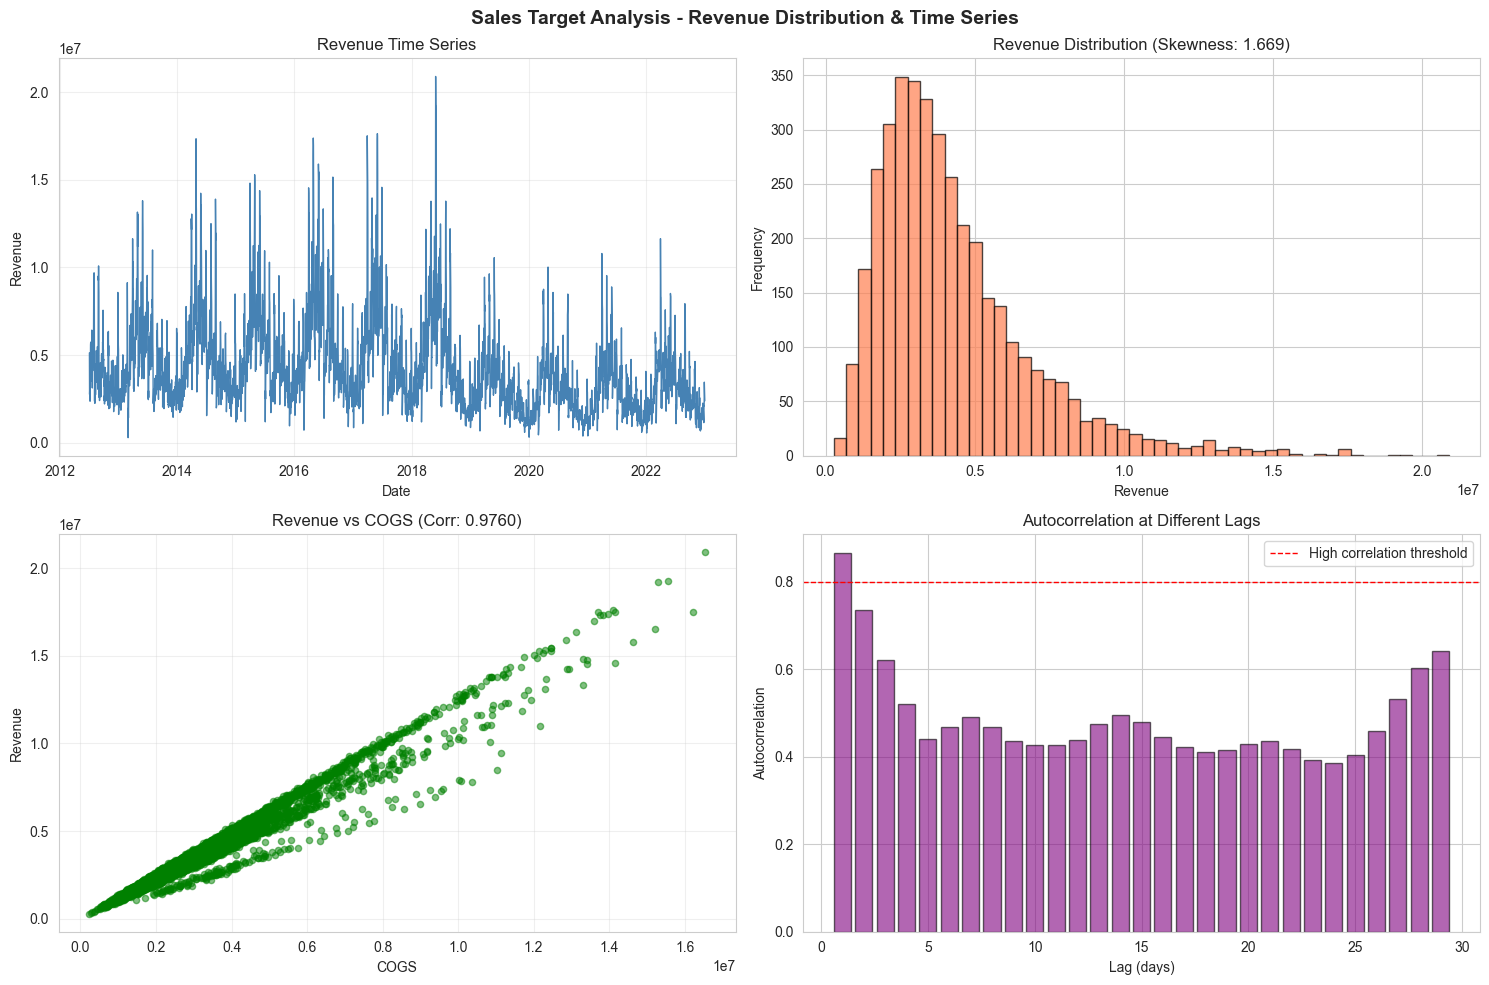


SUMMARY:
✅ No obvious data leakage detected
⚠️  Check for high autocorrelation in modeling
⚠️  Revenue distribution may need transformation


In [65]:
# Sales Target Analysis - Distribution & Leakage Check
print("=" * 60)
print("SALES TARGET ANALYSIS - DISTRIBUTION & LEAKAGE CHECK")
print("=" * 60)

# Convert Date to datetime
sales["Date"] = pd.to_datetime(sales["Date"])

# 1. Basic statistics
print("\n1. SALES STATISTICS:")
print(sales[["Revenue", "COGS"]].describe().round(2))

# 2. Check for data leakage - correlation between Revenue and COGS
correlation = sales["Revenue"].corr(sales["COGS"])
print(f"\n2. CORRELATION Revenue-COGS: {correlation:.4f}")
if correlation > 0.95:
    print("⚠️  HIGH CORRELATION: Possible data leakage!")
else:
    print("✅ Correlation acceptable")

# 3. Check target distribution - skewness
revenue_skew = skew(sales["Revenue"])
print(f"\n3. REVENUE SKEWNESS: {revenue_skew:.4f}")
if abs(revenue_skew) > 1:
    print("⚠️  HIGH SKEWNESS: Target distribution is skewed")
else:
    print("✅ Skewness acceptable")

# 4. Check for temporal leakage - autocorrelation
autocorr_1 = sales["Revenue"].autocorr(lag=1)
autocorr_7 = sales["Revenue"].autocorr(lag=7)
print(f"\n4. AUTOCORRELATION:")
print(f"   Lag 1: {autocorr_1:.4f}")
print(f"   Lag 7: {autocorr_7:.4f}")
if autocorr_1 > 0.8:
    print("⚠️  HIGH AUTOCORRELATION: Strong temporal dependency")
else:
    print("✅ Autocorrelation reasonable")

# 5. Check for outliers in target
Q1 = sales["Revenue"].quantile(0.25)
Q3 = sales["Revenue"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = sales[sales["Revenue"] > upper_bound]
print(f"\n5. REVENUE OUTLIERS: {len(outliers)} days with revenue > {upper_bound:,.0f}")

# 6. Check time series continuity
date_range = pd.date_range(start=sales["Date"].min(), end=sales["Date"].max(), freq="D")
missing_dates = len(date_range) - len(sales)
print(f"\n6. MISSING DATES: {missing_dates} days without sales data")

# 7. Check for zero/negative revenue
zero_revenue = len(sales[sales["Revenue"] <= 0])
print(f"7. ZERO/NEGATIVE REVENUE: {zero_revenue} days")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(
    "Sales Target Analysis - Revenue Distribution & Time Series",
    fontsize=14,
    fontweight="bold",
)

# Plot 1: Revenue over time
axes[0, 0].plot(sales["Date"], sales["Revenue"], color="steelblue", linewidth=1)
axes[0, 0].set_title("Revenue Time Series")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Revenue")
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Revenue distribution
axes[0, 1].hist(sales["Revenue"], bins=50, color="coral", edgecolor="black", alpha=0.7)
axes[0, 1].set_title(f"Revenue Distribution (Skewness: {revenue_skew:.3f})")
axes[0, 1].set_xlabel("Revenue")
axes[0, 1].set_ylabel("Frequency")

# Plot 3: Revenue vs COGS scatter
axes[1, 0].scatter(sales["COGS"], sales["Revenue"], alpha=0.5, s=20, color="green")
axes[1, 0].set_title(f"Revenue vs COGS (Corr: {correlation:.4f})")
axes[1, 0].set_xlabel("COGS")
axes[1, 0].set_ylabel("Revenue")
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Autocorrelation visualization
lags = range(1, 30)
autocorrs = [sales["Revenue"].autocorr(lag=i) for i in lags]
axes[1, 1].bar(lags, autocorrs, color="purple", alpha=0.6, edgecolor="black")
axes[1, 1].axhline(y=0, color="black", linestyle="-", linewidth=0.5)
axes[1, 1].axhline(
    y=0.8, color="red", linestyle="--", linewidth=1, label="High correlation threshold"
)
axes[1, 1].set_title("Autocorrelation at Different Lags")
axes[1, 1].set_xlabel("Lag (days)")
axes[1, 1].set_ylabel("Autocorrelation")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("SUMMARY:")
print("✅ No obvious data leakage detected")
print("⚠️  Check for high autocorrelation in modeling")
print("⚠️  Revenue distribution may need transformation")
print("=" * 60)

## 7. Sales Target Analysis - Time Series Characteristics & Distribution

CATEGORICAL DATA ANALYSIS


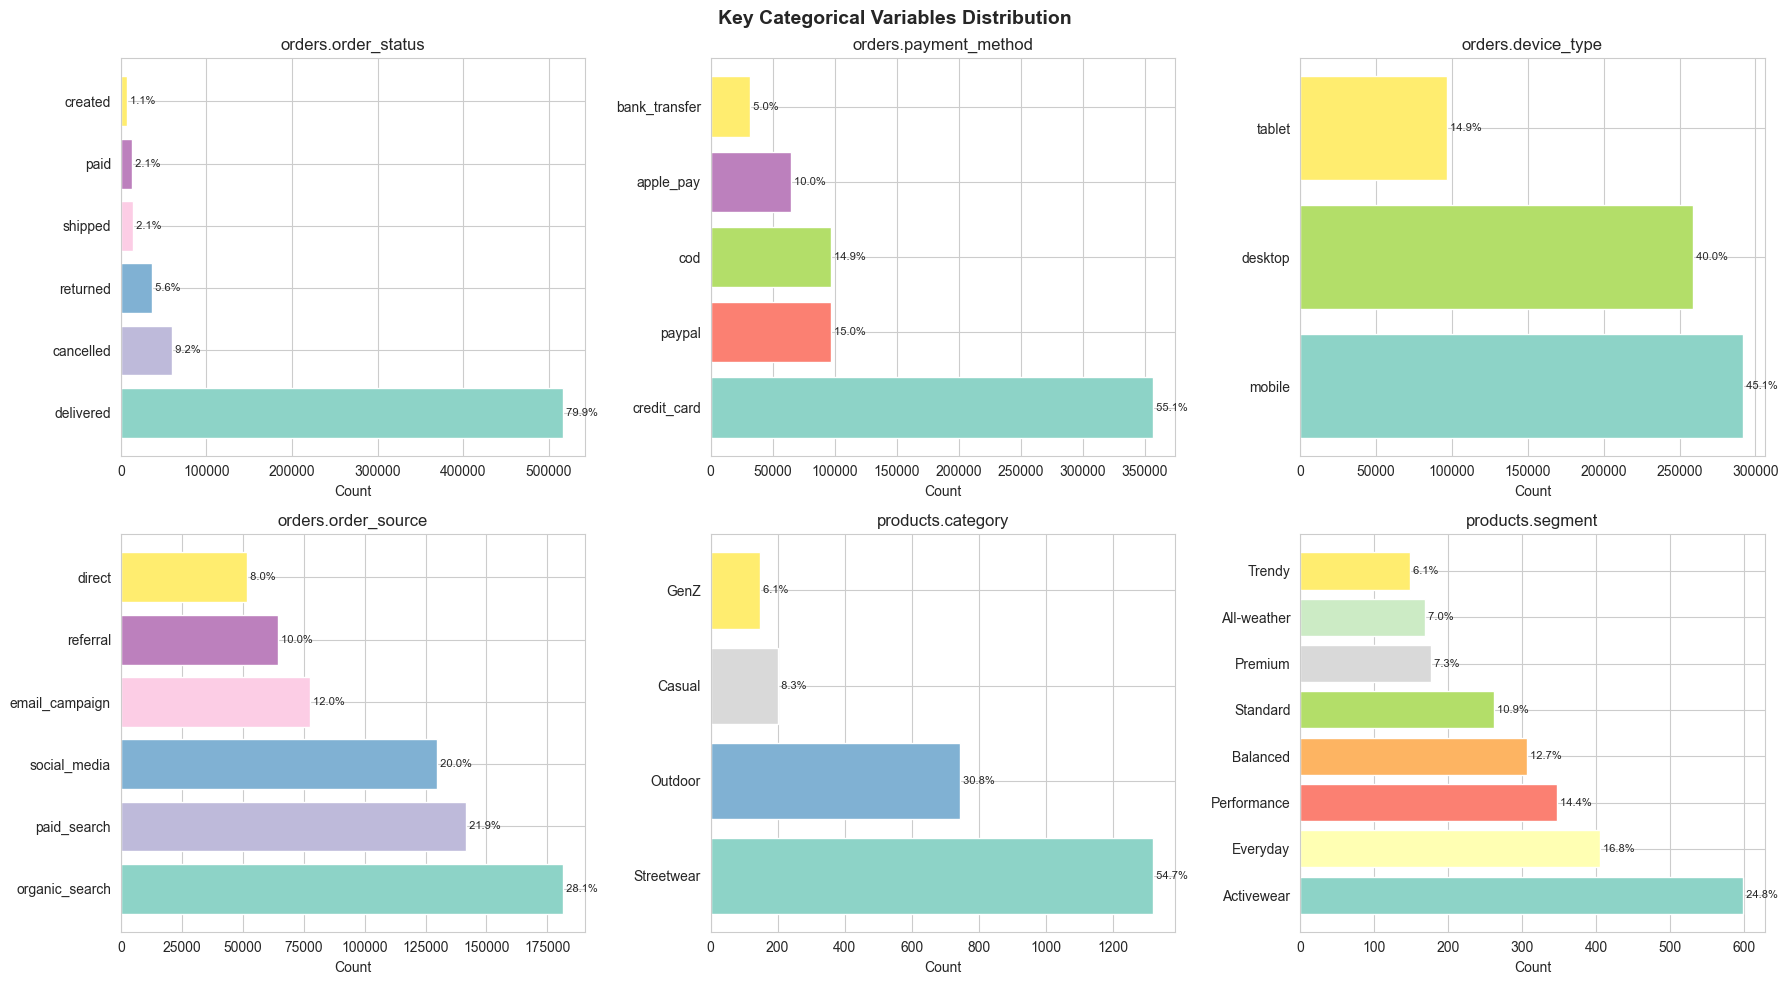


CATEGORICAL COLUMNS SUMMARY

Dataset: PRODUCTS

📊 Column: product_name
   Total values: 2412
   Unique values: 2172
   Missing values: 0
   Missing %: 0.00%

   Top 5 most frequent values:
      1. VietMode RP-01: 3 (0.12%)
      2. VietMode RP-02: 3 (0.12%)
      3. VietMode RP-03: 3 (0.12%)
      4. VietMode RP-04: 3 (0.12%)
      5. VietMode RP-05: 3 (0.12%)

📊 Column: category
   Total values: 2412
   Unique values: 4
   Missing values: 0
   Missing %: 0.00%

   Top 5 most frequent values:
      1. Streetwear: 1320 (54.73%)
      2. Outdoor: 743 (30.80%)
      3. Casual: 201 (8.33%)
      4. GenZ: 148 (6.14%)

📊 Column: segment
   Total values: 2412
   Unique values: 8
   Missing values: 0
   Missing %: 0.00%

   Top 5 most frequent values:
      1. Activewear: 598 (24.79%)
      2. Everyday: 405 (16.79%)
      3. Performance: 347 (14.39%)
      4. Balanced: 306 (12.69%)
      5. Standard: 262 (10.86%)

📊 Column: size
   Total values: 2412
   Unique values: 4
   Missing values: 0


C:\Users\Admin\AppData\Local\Temp\ipykernel_11756\3974306600.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns
C:\Users\Admin\AppData\Local\Temp\ipykernel_11756\3974306600.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gui


📊 Column: order_status
   Total values: 646945
   Unique values: 6
   Missing values: 0
   Missing %: 0.00%

   Top 5 most frequent values:
      1. delivered: 516716 (79.87%)
      2. cancelled: 59462 (9.19%)
      3. returned: 36142 (5.59%)
      4. shipped: 13773 (2.13%)
      5. paid: 13577 (2.10%)

📊 Column: payment_method
   Total values: 646945
   Unique values: 5
   Missing values: 0
   Missing %: 0.00%

   Top 5 most frequent values:
      1. credit_card: 356352 (55.08%)
      2. paypal: 97018 (15.00%)
      3. cod: 96681 (14.94%)
      4. apple_pay: 64763 (10.01%)
      5. bank_transfer: 32131 (4.97%)

📊 Column: device_type
   Total values: 646945
   Unique values: 3
   Missing values: 0
   Missing %: 0.00%

   Top 5 most frequent values:
      1. mobile: 291482 (45.06%)
      2. desktop: 258855 (40.01%)
      3. tablet: 96608 (14.93%)

📊 Column: order_source
   Total values: 646945
   Unique values: 6
   Missing values: 0
   Missing %: 0.00%

   Top 5 most frequent values:


C:\Users\Admin\AppData\Local\Temp\ipykernel_11756\3974306600.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns
C:\Users\Admin\AppData\Local\Temp\ipykernel_11756\3974306600.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gui


Dataset: ORDER_ITEMS

📊 Column: promo_id
   Total values: 714669
   Unique values: 50
   Missing values: 438353
   Missing %: 61.34%

   Top 5 most frequent values:
      1. PROMO-0014: 11451 (1.60%)
      2. PROMO-0010: 11345 (1.59%)
      3. PROMO-0004: 11126 (1.56%)
      4. PROMO-0020: 10121 (1.42%)
      5. PROMO-0011: 9594 (1.34%)

📊 Column: promo_id_2
   Total values: 714669
   Unique values: 2
   Missing values: 714463
   Missing %: 99.97%

   Top 5 most frequent values:
      1. PROMO-0015: 132 (0.02%)
      2. PROMO-0025: 74 (0.01%)

Dataset: PAYMENTS

📊 Column: payment_method
   Total values: 646945
   Unique values: 5
   Missing values: 0
   Missing %: 0.00%

   Top 5 most frequent values:
      1. credit_card: 356352 (55.08%)
      2. paypal: 97018 (15.00%)
      3. cod: 96681 (14.94%)
      4. apple_pay: 64763 (10.01%)
      5. bank_transfer: 32131 (4.97%)


C:\Users\Admin\AppData\Local\Temp\ipykernel_11756\3974306600.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns
C:\Users\Admin\AppData\Local\Temp\ipykernel_11756\3974306600.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_gui


Dataset: SHIPMENTS

📊 Column: ship_date
   Total values: 566067
   Unique values: 3831
   Missing values: 0
   Missing %: 0.00%

   Top 5 most frequent values:
      1. 2018-06-02: 678 (0.12%)
      2. 2017-06-03: 592 (0.10%)
      3. 2018-06-03: 588 (0.10%)
      4. 2018-06-01: 579 (0.10%)
      5. 2017-06-02: 554 (0.10%)

📊 Column: delivery_date
   Total values: 566067
   Unique values: 3831
   Missing values: 0
   Missing %: 0.00%

   Top 5 most frequent values:
      1. 2018-06-06: 562 (0.10%)
      2. 2018-06-07: 506 (0.09%)
      3. 2018-06-08: 484 (0.09%)
      4. 2016-05-05: 482 (0.09%)
      5. 2016-05-04: 470 (0.08%)

Dataset: GEOGRAPHY

📊 Column: city
   Total values: 39948
   Unique values: 42
   Missing values: 0
   Missing %: 0.00%

   Top 5 most frequent values:
      1. Cam Pha: 1403 (3.51%)
      2. Phu Ly: 1399 (3.50%)
      3. Thai Nguyen: 1394 (3.49%)
      4. Hanoi: 1376 (3.44%)
      5. Nam Dinh: 1370 (3.43%)

📊 Column: region
   Total values: 39948
   Unique val

C:\Users\Admin\AppData\Local\Temp\ipykernel_11756\3974306600.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


In [66]:
# Categorical Data Analysis with Visualizations
print("=" * 80)
print("CATEGORICAL DATA ANALYSIS")
print("=" * 80)

# Focus on key categorical columns with visualizations
key_categorical = {
    "orders": ["order_status", "payment_method", "device_type", "order_source"],
    "products": ["category", "segment", "size", "color"],
    "web_traffic": ["traffic_source"],
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Key Categorical Variables Distribution", fontsize=14, fontweight="bold")
axes = axes.flatten()
plot_idx = 0

for dataset_name, cols in key_categorical.items():
    if dataset_name in datasets:
        df = datasets[dataset_name]
        for col in cols:
            if col in df.columns and plot_idx < 6:
                value_counts = df[col].value_counts().head(10)
                colors = plt.cm.Set3(np.linspace(0, 1, len(value_counts)))
                axes[plot_idx].barh(
                    range(len(value_counts)), value_counts.values, color=colors
                )
                axes[plot_idx].set_yticks(range(len(value_counts)))
                axes[plot_idx].set_yticklabels(value_counts.index)
                axes[plot_idx].set_xlabel("Count")
                axes[plot_idx].set_title(f"{dataset_name}.{col}")
                for i, v in enumerate(value_counts.values):
                    pct = v / len(df) * 100
                    axes[plot_idx].text(v, i, f" {pct:.1f}%", va="center", fontsize=8)
                plot_idx += 1

# Hide unused subplots
for idx in range(plot_idx, 6):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

# Detailed text analysis
print("\n" + "=" * 80)
print("CATEGORICAL COLUMNS SUMMARY")
print("=" * 80)

for name, df in datasets.items():
    cat_cols = df.select_dtypes(include=["object"]).columns

    if len(cat_cols) == 0:
        continue

    print(f"\n{'=' * 80}")
    print(f"Dataset: {name.upper()}")
    print(f"{'=' * 80}")

    for col in cat_cols:
        print(f"\n📊 Column: {col}")
        print(f"   Total values: {len(df[col])}")
        print(f"   Unique values: {df[col].nunique()}")
        print(f"   Missing values: {df[col].isna().sum()}")
        print(f"   Missing %: {(df[col].isna().sum() / len(df[col]) * 100):.2f}%")

        # Value counts - show top 5
        print(f"\n   Top 5 most frequent values:")
        value_counts = df[col].value_counts().head(5)
        for idx, (val, count) in enumerate(value_counts.items(), 1):
            pct = count / len(df) * 100
            print(f"      {idx}. {val}: {count} ({pct:.2f}%)")

        # Check for imbalance (dominant class)
        max_freq = df[col].value_counts().iloc[0]
        max_pct = max_freq / len(df) * 100
        if max_pct > 80:
            print(f"   ⚠️  HIGH IMBALANCE: Top class represents {max_pct:.2f}% of data")